# Field Analylsis

## Load data

In [1]:
import geopandas as gpd

fields = gpd.read_parquet("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/02_NDVI_Scale_Sensitivity/01_FTW download and field analysis and sample data extraction/sylhet field/sylhet_fields.parquet")
fields.head()

,time,label,confidence_mean,confidence_median,confidence_min,geometry,chunk_id
0,2025-01-01,field,0.472534,0.472534,0.472534,"POLYGON ((92.19554 24.77362, 92.19554 24.77353...",N24E092
1,2025-01-01,field,0.472534,0.472534,0.472534,"POLYGON ((92.195 24.77425, 92.195 24.77416, 92...",N24E092
2,2025-01-01,field,0.472534,0.472534,0.472534,"POLYGON ((92.19536 24.77389, 92.19536 24.77371...",N24E092
3,2025-01-01,field,0.472534,0.472534,0.472534,"POLYGON ((92.19401 24.77389, 92.19401 24.77371...",N24E092
4,2025-01-01,field,0.472534,0.472534,0.472534,"POLYGON ((92.19446 24.77389, 92.19446 24.7738,...",N24E092


## Sanity check

In [2]:
fields.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [3]:
fields.geometry.geom_type.value_counts()

,count
Polygon,400983
MultiPolygon,106


## CRS Conversion

In [4]:
fields = fields.to_crs("EPSG:32646")

## Area + Parameter

In [5]:
fields["area_m2"] = fields.area
fields["perimeter_m"] = fields.length

## Core Statistics

In [6]:
fields["area_m2"].describe()

,area_m2
count,4.010890e+05
mean,1.312119e+03
std,2.085659e+04
min,1.058494e-04
25%,1.805168e+02
50%,4.506350e+02
75%,9.910031e+02
max,9.170623e+06


## Distribution plot

Remove the extreme outlier.

In [7]:
fields_clean = fields[
    (fields["area_m2"] >= 100) &
    (fields["area_m2"] <= 50000)
]

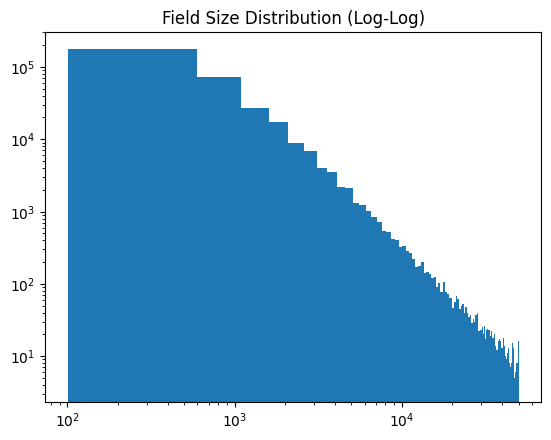

In [8]:
import matplotlib.pyplot as plt

plt.hist(fields_clean["area_m2"], bins=100)
plt.xscale("log")
plt.yscale("log")
plt.title("Field Size Distribution (Log-Log)")
plt.show()

# Experment Design

## Create Field Classes

In [9]:
def classify(area):
    if area < 300:
        return "small"
    elif area < 1500:
        return "medium"
    elif area < 5000:
        return "large"
    else:
        return "very_large"

fields["size_class"] = fields["area_m2"].apply(classify)


## Check Class Balance

In [10]:
fields["size_class"].value_counts()

,count
size_class,
medium,179185
small,160386
large,48871
very_large,12647


## Create stratified sample

In [11]:
sample_fields = (
    fields.groupby("size_class", group_keys=False)
    .apply(lambda x: x.sample(n=50, random_state=42))
)

/tmp/ipykernel_5744/865374055.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=50, random_state=42))


In [12]:
sample_fields["size_class"].value_counts()

,count
size_class,
large,50
medium,50
small,50
very_large,50


## Create uniquie ID

In [13]:
sample_fields = sample_fields.reset_index(drop=True)

sample_fields["field_id"] = range(1, len(sample_fields) + 1)

## Create shape index

Interpretation:

    ≈1      → circular / compact field
    >1      → irregular field
    >>1     → highly irregular field

In [14]:
import numpy as np

sample_fields["shape_index"] = (
    sample_fields["perimeter_m"] /
    (2 * np.sqrt(np.pi * sample_fields["area_m2"]))
)

## Save field statistics

In [15]:
field_stats = sample_fields[
    ["field_id",
     "area_m2",
     "perimeter_m",
     "shape_index",
     "size_class"]
]

field_stats.to_csv("field_stats.csv", index=False)

## Save Sample field shapefile

## Again convert to the lan-lat

In [16]:
sample_fields_gcs = sample_fields.to_crs("EPSG:4326")

In [17]:
sample_fields_gcs.to_file(
    "sample_fields.shp"
)

/tmp/ipykernel_5744/1130017553.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sample_fields_gcs.to_file(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Field time created as String field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'confidence_mean' to 'confidence'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'confidence_median' to 'confiden_1'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'confidence_min' to 'confiden_2'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'perimeter_m' to 'perimeter_'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: R